In [1]:
from utils.binaries import *
from utils.plotting import *
from utils.auger.fd import NightSkyBackground

23:09:27 (  +11.8s) [INFO   ] -- import logging
23:09:27 (  +211ms) [INFO   ] -- import numpy as np
23:09:27 (   +17ms) [INFO   ] -- import uncertainties
23:09:28 (  +999ms) [INFO   ] -- import pandas as pd
23:09:28 (    +2ms) [WARNING] -- pandas support to be dropped at some point!
23:09:28 (    +3ms) [INFO   ] -- import binaries.tools as tools
23:09:28 (    +4ms) [INFO   ] -- set MONI_PATH = PosixPath('/cr/work/filip/monit_and_sd')
23:09:28 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/cr/work/filip/monit_and_sd')
23:09:28 (    +1ms) [INFO   ] -- set PLOT_PATH = PosixPath('/cr/data01/filip/plots')
23:09:28 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/cr/data01/filip/Data')
23:09:28 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/cr/data01/filip/xy-calibration')
23:09:28 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/cr/data01/filip/offline/install')
23:09:29 (  +667ms) [INFO   ] -- import matplotlib.pyplot as plt
23:09:30 (   +1.1s) [INFO   ] -- import seaborn a

In [2]:
CO4 = NightSkyBackground.CameraNSB("Coihueco", 4)
# pix = CO4.get_pixel(210).df

loading /cr/tempdata01/filip/nsb_data/Coihueco4/nsb_2014-05-01_to_2014-06-01.pkl...
180 files (15.0 yrs) loaded for Coihueco #4


In [3]:
def get_drift(pixel):

    xt = pixel["days_since_start"].values
    y = pixel["night_sky_background"].values

    popt, pcov = np.polyfit(xt, y, deg=1, cov=True)
    f = np.poly1d(popt)
    popt = uncertainties.correlated_values(popt, pcov)
    drift = popt[0]/f(0) * 36500

    return f, drift

9 outliers removed for pixel = 210


/cr/users/filip/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


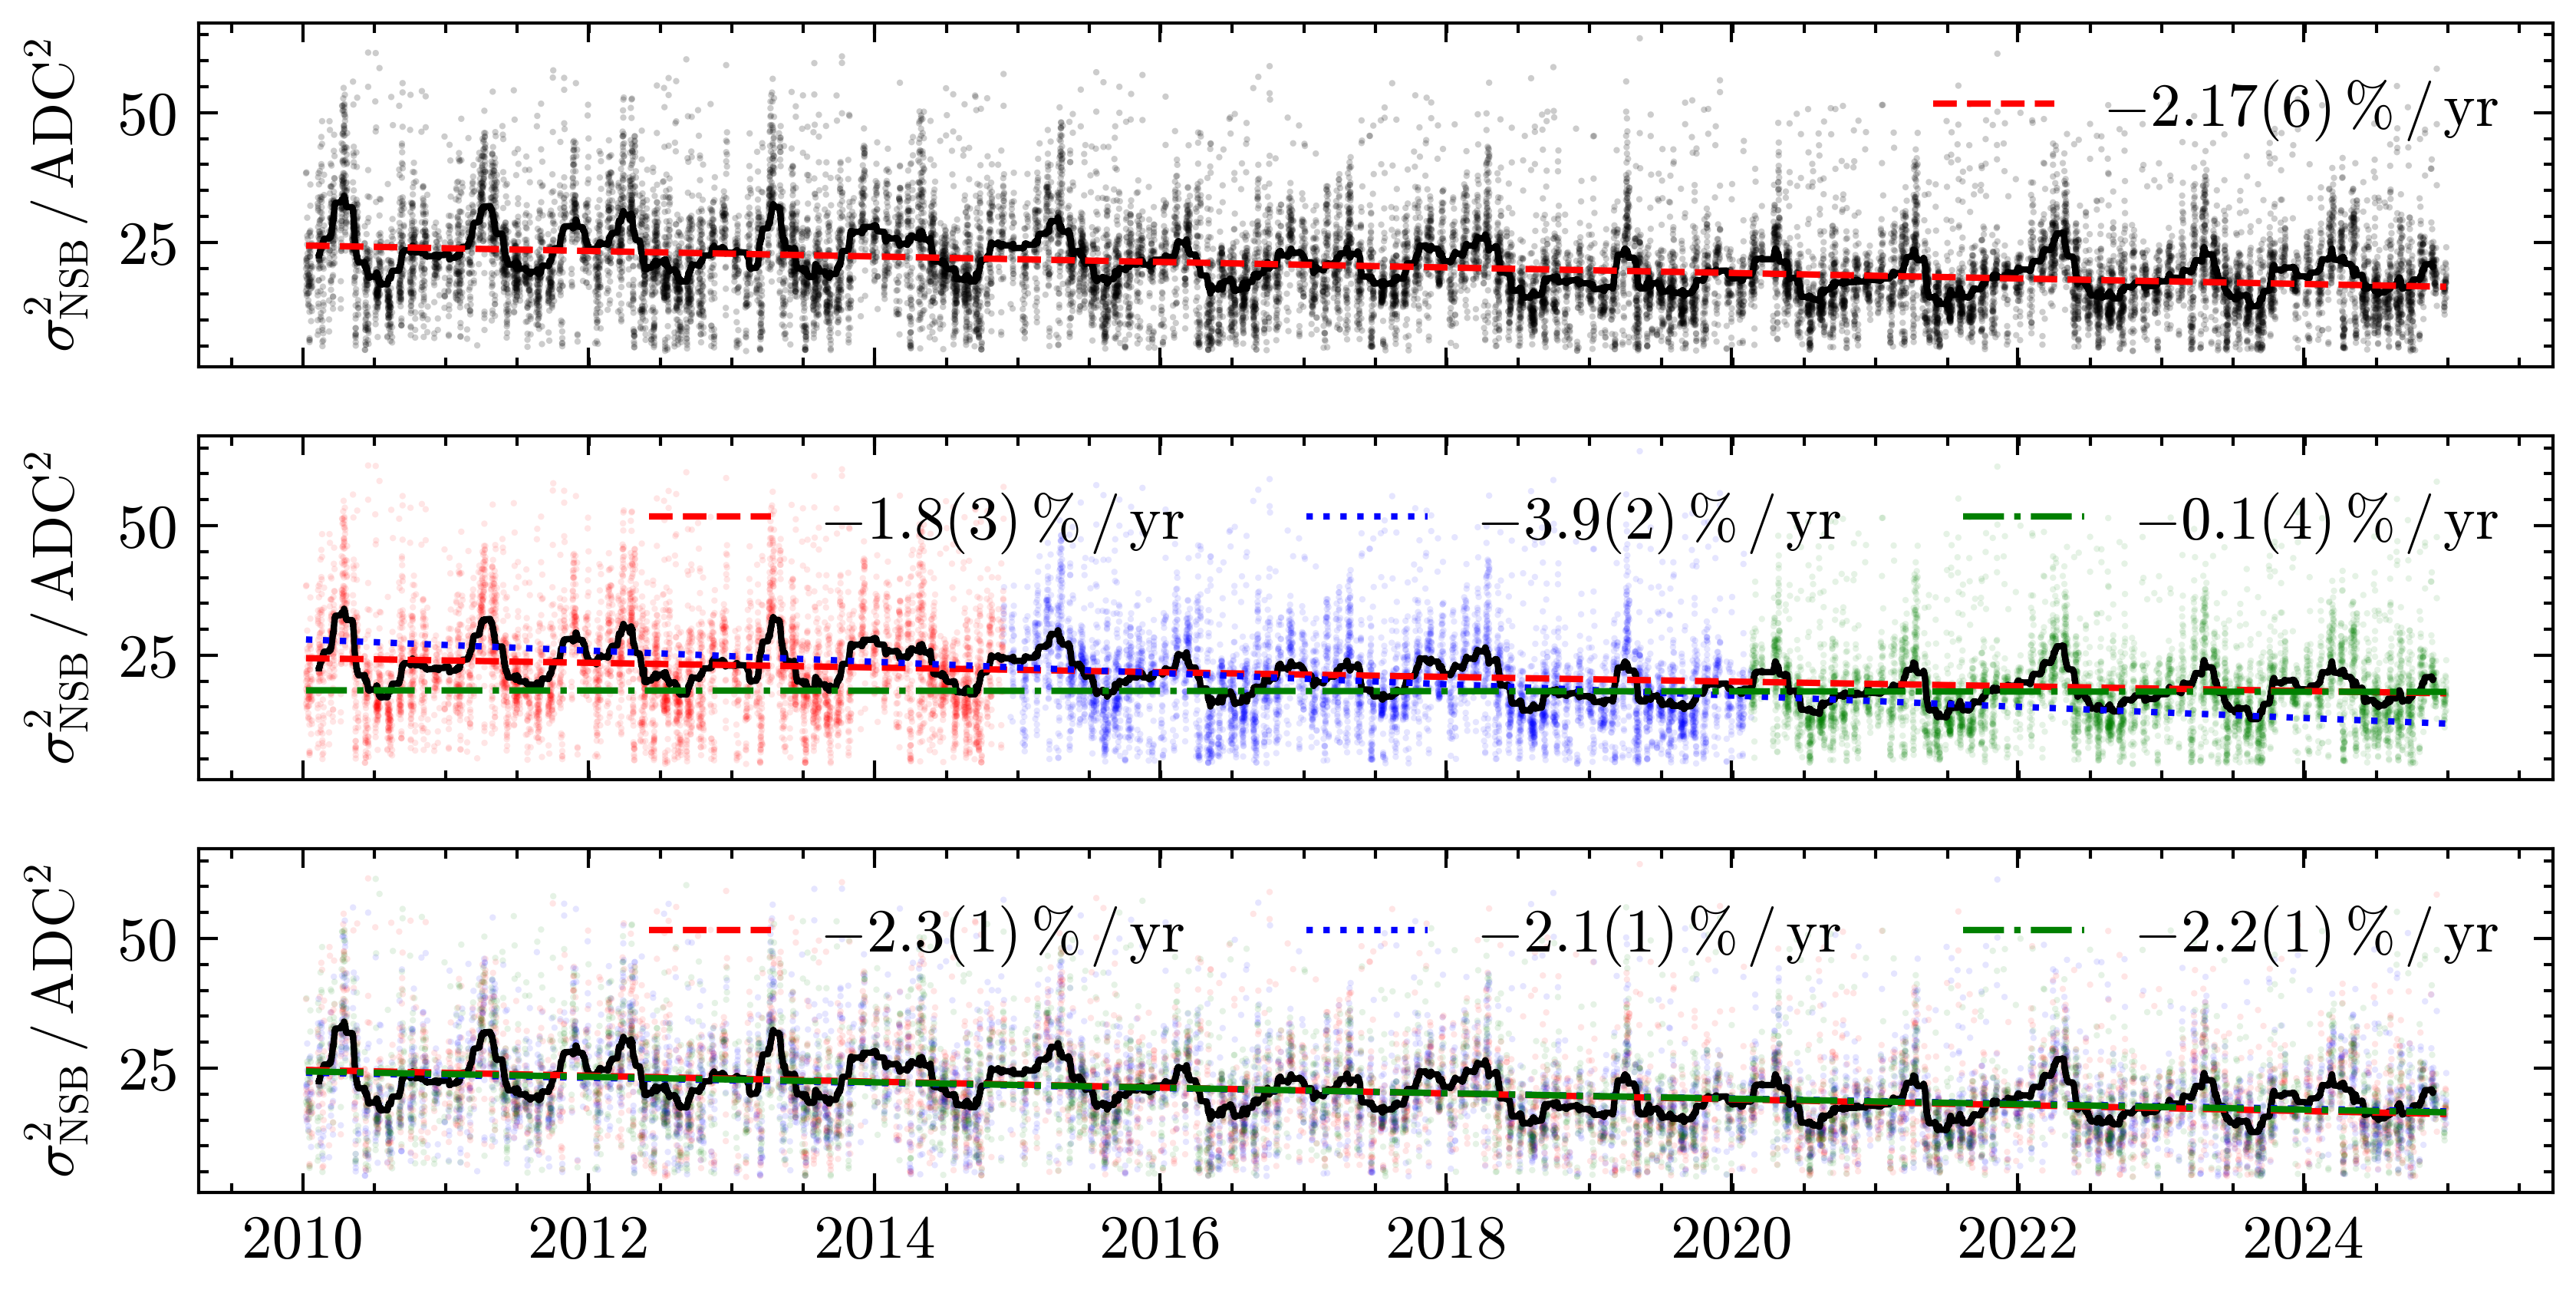

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, sharey=True)

pix = CO4.get_pixel(210).df
X, Y = tools.running_mean(pix['datetime'], pix['night_sky_background'], 7 * 30)

# full dataset
ax1.scatter(pix['datetime'], pix['night_sky_background'], s=1, ec='none', alpha=0.2)
ax1.plot(X, Y, marker='none')
f, drift = get_drift(pix)
ax1.plot(pix['datetime'], f(pix['days_since_start']), marker='none', label=f"${drift:+.1uS}\,\%\,/\,\mathrm{{yr}}$")
ax1.legend()

# split in time
split = len(pix) // 3
df1, df2, df3 = pix.iloc[:split], pix.iloc[split:2*split], pix.iloc[2*split:]
ax2.scatter(df1['datetime'], df1['night_sky_background'], s=1, ec='none', c='r', alpha=0.1)
ax2.scatter(df2['datetime'], df2['night_sky_background'], s=1, ec='none', c='b', alpha=0.1)
ax2.scatter(df3['datetime'], df3['night_sky_background'], s=1, ec='none', c='g', alpha=0.1)
f1, drift1 = get_drift(df1)
f2, drift2 = get_drift(df2)
f3, drift3 = get_drift(df3)
ax2.plot(X, Y, marker='none')
ax2.plot(pix['datetime'], f1(pix['days_since_start']), marker='none', c='r', label=f"${drift1:+.1uS}\,\%\,/\,\mathrm{{yr}}$")
ax2.plot(pix['datetime'], f2(pix['days_since_start']), marker='none', c='b', label=f"${drift2:+.1uS}\,\%\,/\,\mathrm{{yr}}$")
ax2.plot(pix['datetime'], f3(pix['days_since_start']), marker='none', c='g', label=f"${drift3:+.1uS}\,\%\,/\,\mathrm{{yr}}$")

ax2.legend(ncol=3)

# split randomly
shuffled = pix.sample(frac=1)
df1, df2, df3 = np.array_split(shuffled, 3)
ax3.scatter(df1['datetime'], df1['night_sky_background'], s=1, ec='none', c='r', alpha=0.1)
ax3.scatter(df2['datetime'], df2['night_sky_background'], s=1, ec='none', c='b', alpha=0.1)
ax3.scatter(df3['datetime'], df3['night_sky_background'], s=1, ec='none', c='g', alpha=0.1)
f1, drift1 = get_drift(df1)
f2, drift2 = get_drift(df2)
f3, drift3 = get_drift(df3)
ax3.plot(X, Y, marker='none')
ax3.plot(pix['datetime'], f1(pix['days_since_start']), marker='none', c='r', label=f"${drift1:+.1uS}\,\%\,/\,\mathrm{{yr}}$")
ax3.plot(pix['datetime'], f2(pix['days_since_start']), marker='none', c='b', label=f"${drift2:+.1uS}\,\%\,/\,\mathrm{{yr}}$")
ax3.plot(pix['datetime'], f3(pix['days_since_start']), marker='none', c='g', label=f"${drift3:+.1uS}\,\%\,/\,\mathrm{{yr}}$")
ax3.legend(ncol=3)

ax1.set_ylabel("$\sigma^2_\mathrm{NSB}\,/\,\mathrm{ADC}^2$", fontsize=9)
ax2.set_ylabel("$\sigma^2_\mathrm{NSB}\,/\,\mathrm{ADC}^2$", fontsize=9)
ax3.set_ylabel("$\sigma^2_\mathrm{NSB}\,/\,\mathrm{ADC}^2$", fontsize=9)
plot.apply_datetime_format(ax3)

plot.save(fig, "nsb_thesis_plots/drift_co4")

In [ ]:
# def get_drift2(xt, y):

#     popt, pcov = np.polyfit(xt, y, deg=1, cov=True)
#     f = np.poly1d(popt)
#     drift = popt[0]/f(0) * 36500

#     return drift

# window_size = 5000
# times, drifts, complete, duration = [], [], [], []

# X = pix['days_since_start'].rolling(window_size)
# Y = pix['night_sky_background'].rolling(window_size)

# for x, y in zip(X, Y):

#     if len(x) < window_size: continue

#     times.append(x.mean())
#     drifts.append(get_drift2(x, y))
#     complete.append(len(x) == window_size)
#     duration.append(x.iloc[-1] - x.iloc[0])

# # for year, df in pix.groupby(pix['datetime'].dt.year):
    
# #     _, drift = get_drift(df)
# #     val.append(drift.nominal_value)
# #     err.append(drift.std_dev)
# #     years.append(year)

# # plt.errorbar(years, val, err)

In [11]:
def get_drift2(xt, y):

    popt, pcov = np.polyfit(xt, y, deg=1, cov=True)
    f = np.poly1d(popt)
    drift = popt[0]/f(0) * 36500

    return drift

# CO4 pixel 210

In [8]:
pixel210 = CO4.get_pixel(210)
pixel210df = pixel210.df

model = pixel210.get_model(n_peaks=2, rel_height=0.4)
pixel210df['seasonal_removed'] = pixel210df['night_sky_background'] - (model(pixel210df['days_since_start']) - pixel210._periodogram.offset())

# pix['seasonal_removed']

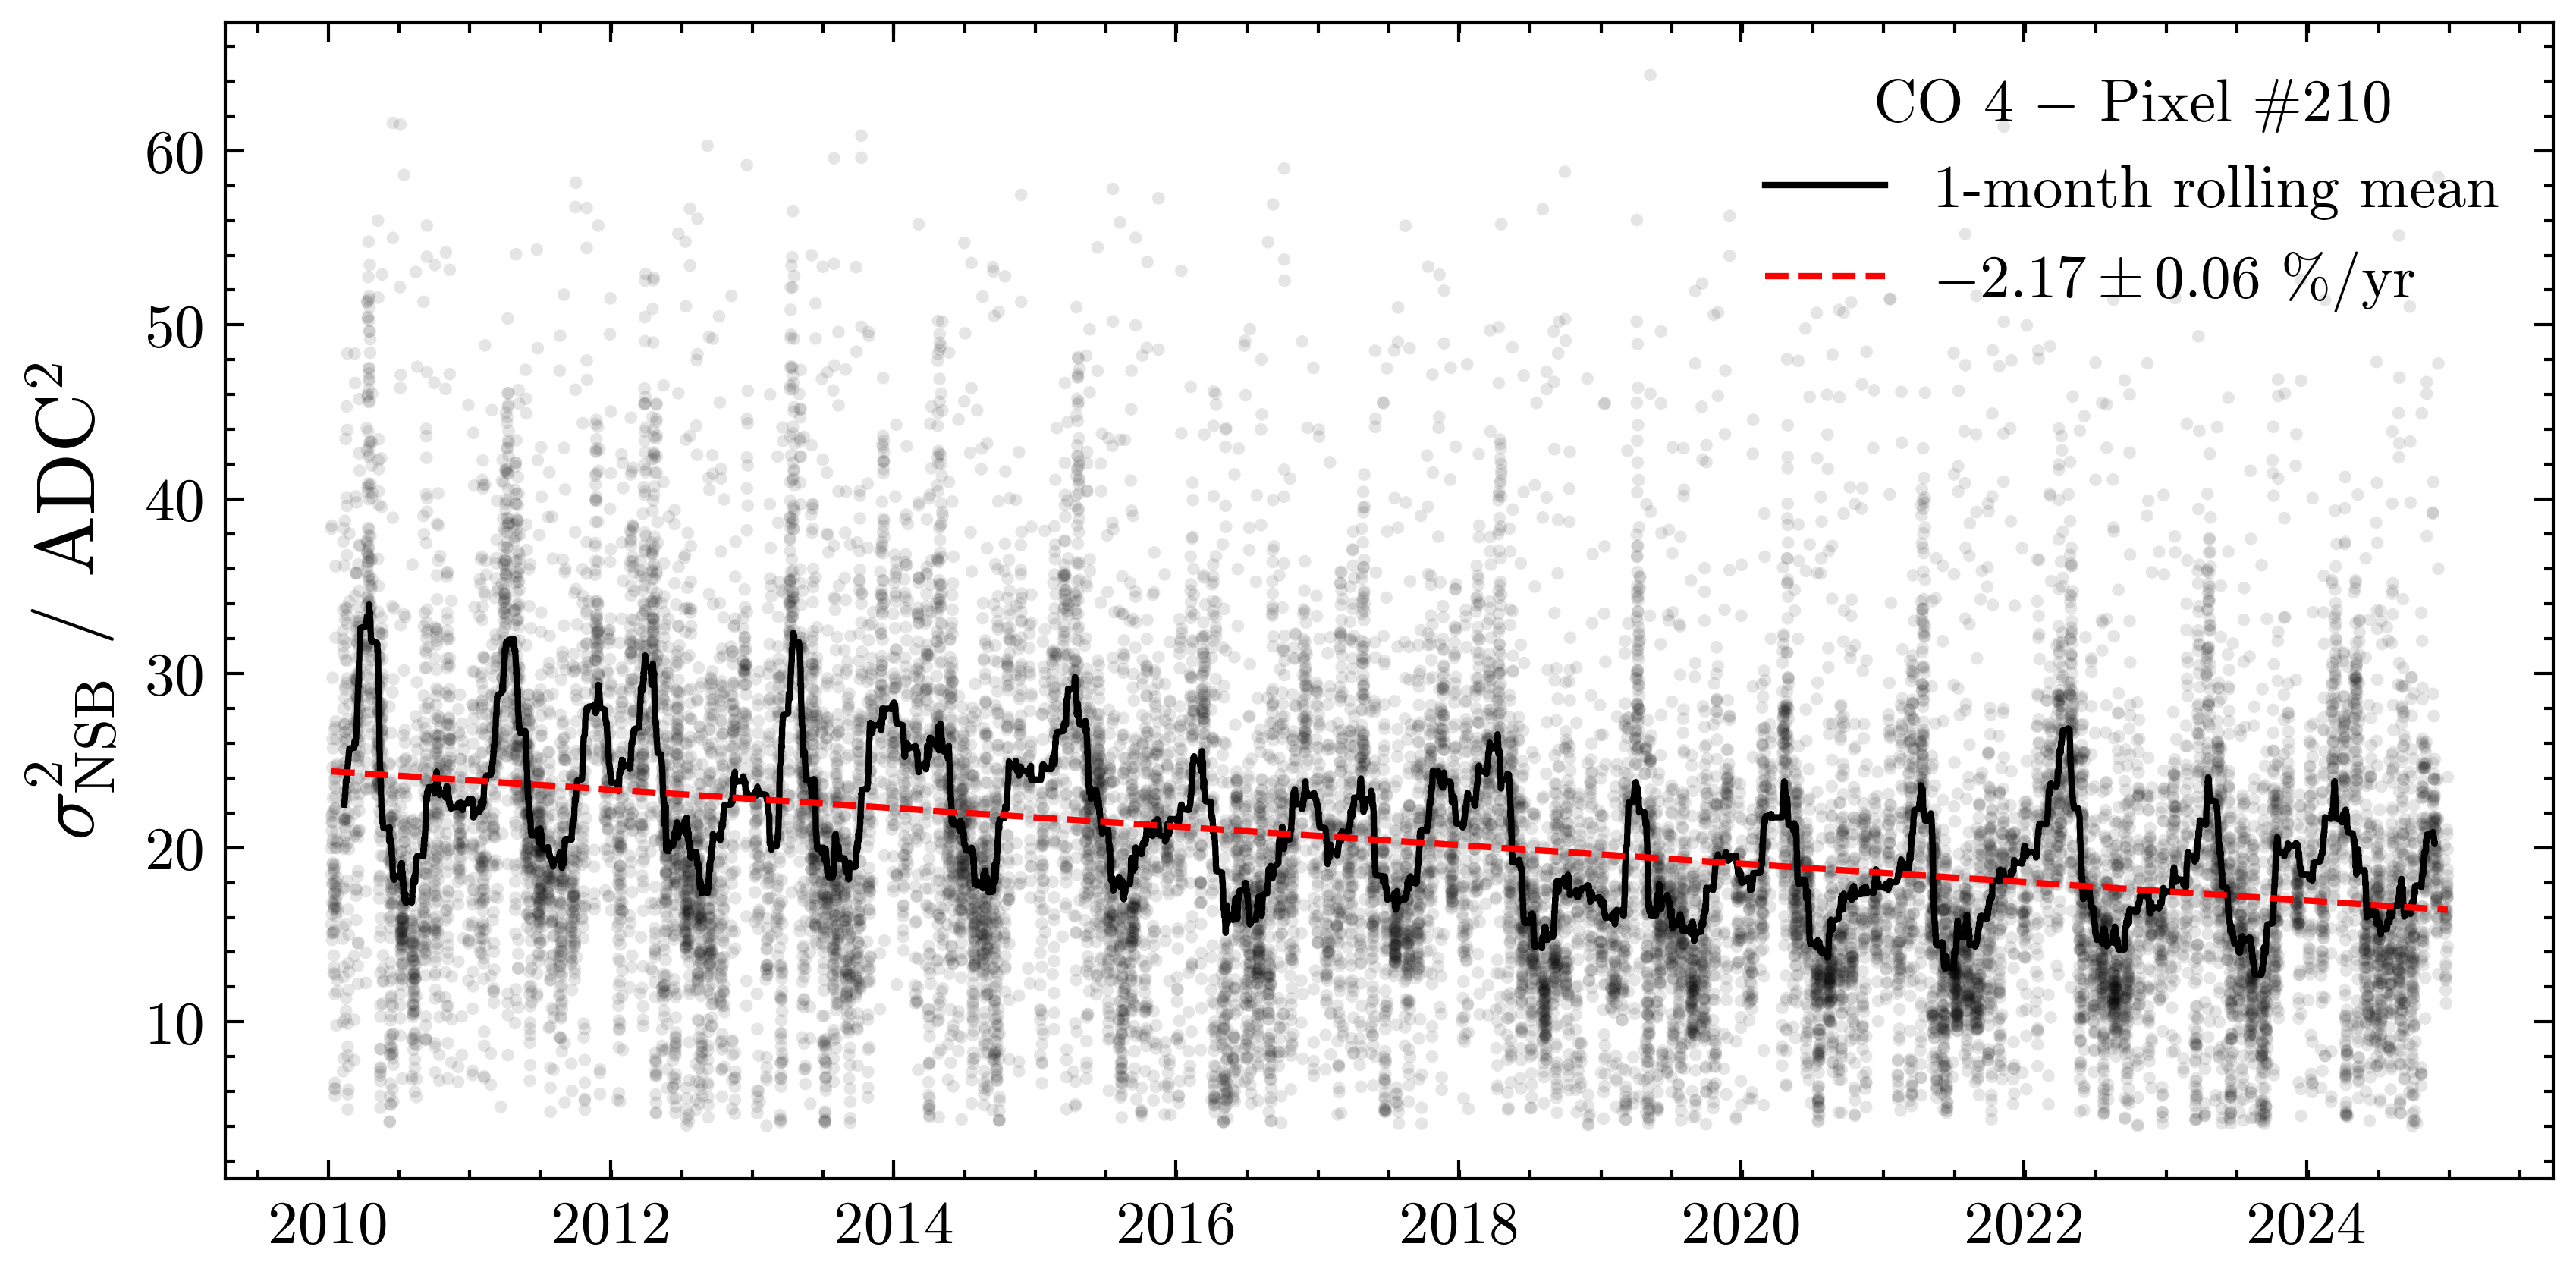

In [ ]:
pixel210.show(show_mean=True, show_drift=True)
plot.save(plt.gcf(), "pixel_210")

In [12]:
from datetime import datetime, timedelta
from scipy.signal import savgol_filter

start = pixel210df['datetime'].min()
stop = pixel210df['datetime'].max()
all_drifts, times = [], []

window_size = 365*3 + 366
while start < stop:

    print(start, end='\r')

    df = pixel210df[pixel210df['datetime'].between(start, start + timedelta(days=window_size))]

    if len(df) < 5000: break

    drift = get_drift2(df['days_since_start'], df['seasonal_removed'])
    times.append(df['datetime'].mean())
    all_drifts.append(drift)

    start += timedelta(days=30)

23:12:08 (   +8.4s) [DEBUG  ] -- font size set to 9.5
23:12:08 (    +3ms) [DEBUG  ] -- label size set to 13.0
23:12:08 (    +1ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
23:12:08 (    +2ms) [DEBUG  ] -- markersize set to 2.0
23:12:08 (    +1ms) [DEBUG  ] -- usetex set to False


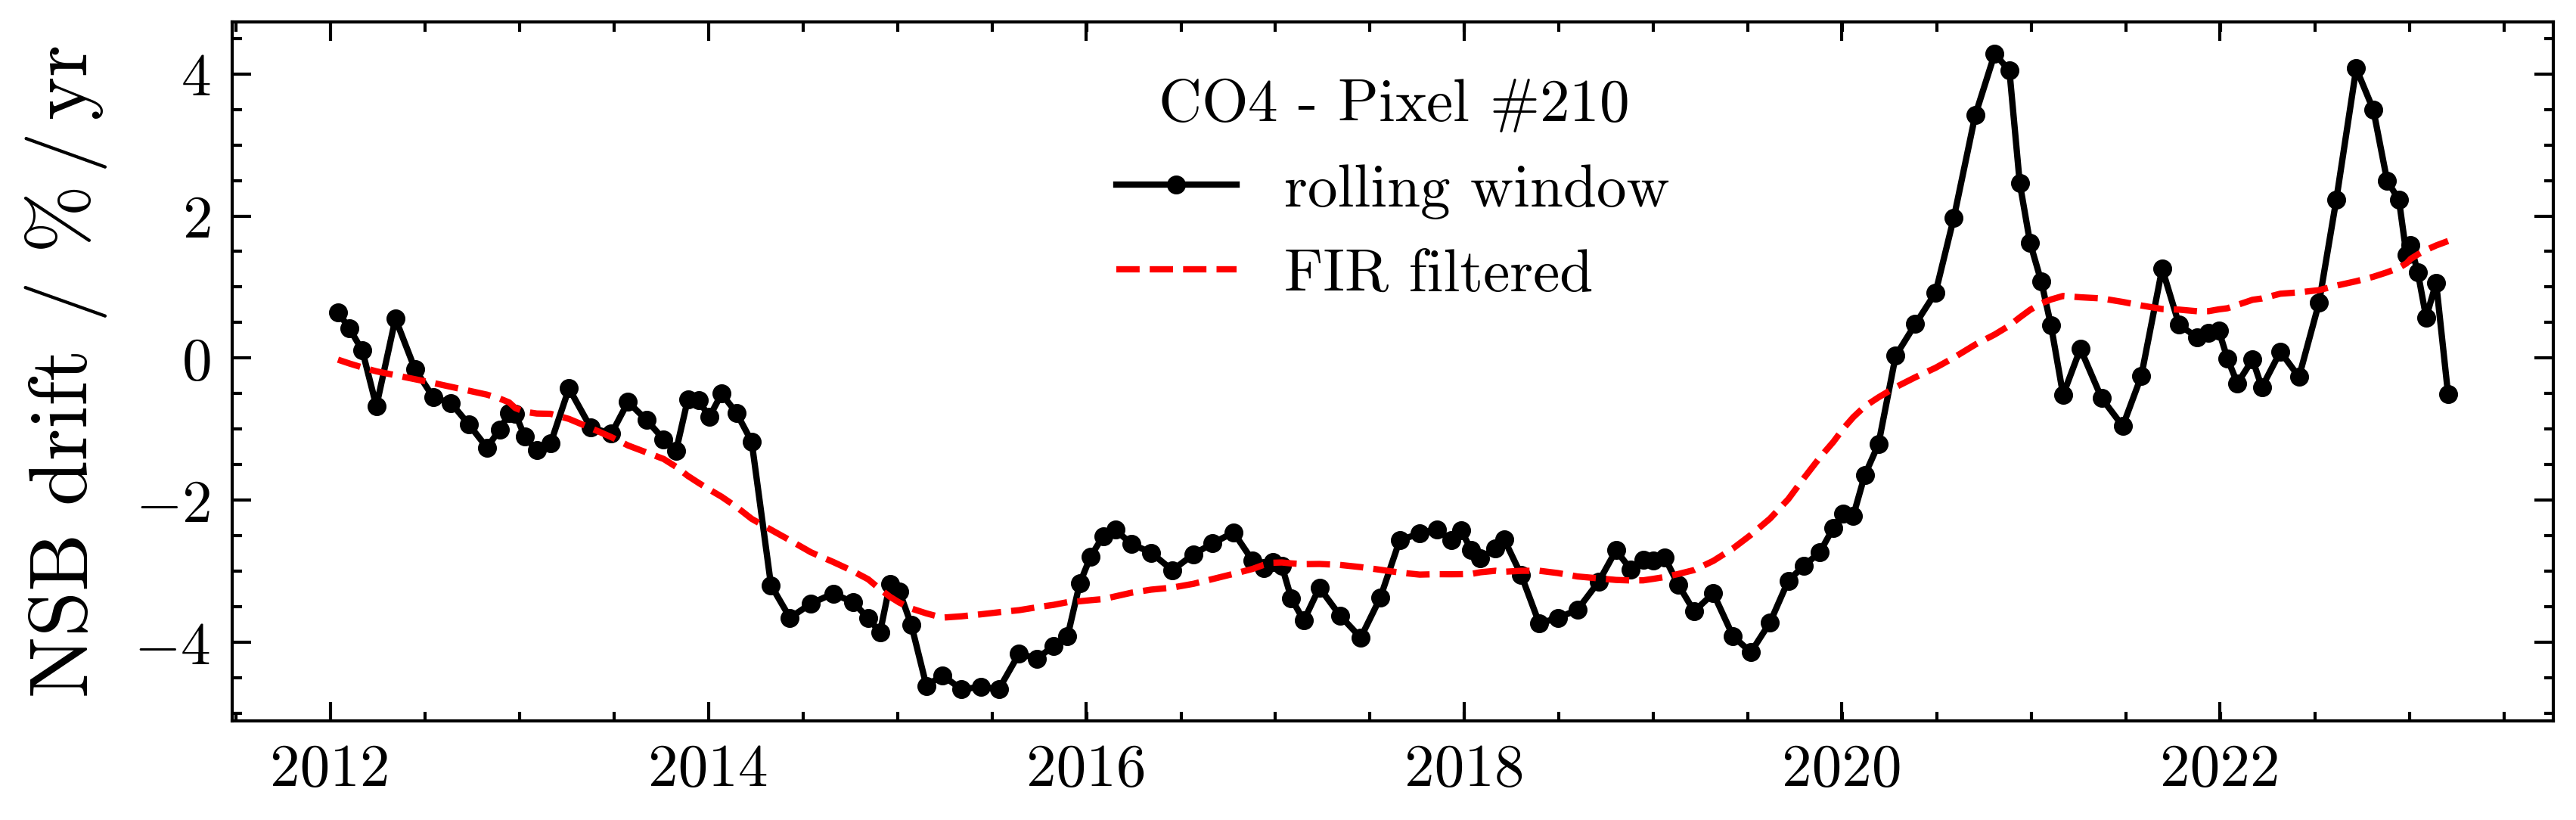

In [13]:
set_plt_style('slim')

fig = plt.figure(figsize=[6.6, 2])

plt.plot(times, all_drifts, label='rolling window')

drifts_filtered = savgol_filter(all_drifts, 24, 1)
plt.plot(times, drifts_filtered, marker='none', label='FIR filtered')

plt.legend(title='CO4 - Pixel $\#210$')

plt.ylabel("NSB drift / $\%\,/\,\mathrm{yr}$")
# plt.ylim(-5, 5)
plot.save(plt.gcf(), "nsb_thesis_plots/rolling_window_drift_co4")

# LM1 pixel 210

In [14]:
from utils.auger.fd import NightSkyBackground
LM1 = NightSkyBackground.CameraNSB("LosMorados", 1)

loading /cr/tempdata01/filip/nsb_data/LosMorados1/nsb_2014-05-01_to_2014-06-01.pkl...
179 files (14.9 yrs) loaded for LosMorados #1


In [ ]:
pixel210 = LM1.get_pixel(199)
pixel210df = pixel210.df

model = pixel210.get_model(n_peaks=2, rel_height=0.4)
pixel210df['seasonal_removed'] = pixel210df['night_sky_background'] - (model(pixel210df['days_since_start']) - pixel210._periodogram.offset())

In [ ]:
from datetime import datetime, timedelta
from scipy.signal import savgol_filter

start = pixel210df['datetime'].min()
stop = pixel210df['datetime'].max()
all_drifts, times = [], []

window_size = 365*3 + 366
while start < stop:

    print(start, end='\r')

    df = pixel210df[pixel210df['datetime'].between(start, start + timedelta(days=window_size))]

    if len(df) < 5000: break

    drift = get_drift2(df['days_since_start'], df['seasonal_removed'])
    times.append(df['datetime'].mean())
    all_drifts.append(drift)

    start += timedelta(days=30)

In [ ]:
set_plt_style('slim')

fig = plt.figure(figsize=[6.6, 2])

plt.plot(times, all_drifts, label='rolling window')

drifts_filtered = savgol_filter(all_drifts, 24, 1)
plt.plot(times, drifts_filtered, marker='none', label='FIR filtered')

plt.legend(title='LM1 - Pixel $\#199$')

plt.ylabel("NSB drift / $\%\,/\,\mathrm{yr}$")
# plt.ylim(-5, 5)
plot.save(plt.gcf(), "nsb_thesis_plots/rolling_window_drift_lm1")

# TOGETHER

In [28]:
df_co4.df['night_sky_background']

6342089    15.616597
6342090    18.467597
6342091    19.962097
6342092    38.314097
6342093    21.492597
             ...    
278587     14.301518
278588     18.395018
278589     18.745018
278590     19.910018
278591     24.043518
Name: night_sky_background, Length: 20623, dtype: float64

In [45]:
df_co4 = CO4.get_pixel(210)
df_lm1 = LM1.get_pixel(199)

model_co4 = df_co4.get_model(n_peaks=2, rel_height=0.4)
model_lm1 = df_lm1.get_model(n_peaks=2, rel_height=0.4)

df_co4.df['seasonal_removed'] = df_co4.df['night_sky_background'] - (model_co4(df_co4.df['days_since_start']) - df_co4._periodogram.offset())
df_lm1.df['seasonal_removed'] = df_lm1.df['night_sky_background'] - (model_lm1(df_lm1.df['days_since_start']) - df_lm1._periodogram.offset())

237 outliers removed for pixel = 199


In [46]:
from datetime import datetime, timedelta
from scipy.signal import savgol_filter

start = np.min([df_co4.df['datetime'].min(), df_lm1.df['datetime'].min()])
stop = np.max([df_co4.df['datetime'].max(), df_lm1.df['datetime'].max()])

drifts_co4, times_co4 = [], []
drifts_lm1, times_lm1 = [], []

window_size = 365*3 + 366
while start < stop:

    print(start, end='\r')

    df_co4_part = df_co4.df[df_co4.df['datetime'].between(start, start + timedelta(days=window_size))]
    df_lm1_part = df_lm1.df[df_lm1.df['datetime'].between(start, start + timedelta(days=window_size))]

    if len(df_co4_part) >= 5000:
        drift = get_drift2(df_co4_part['days_since_start'], df_co4_part['seasonal_removed'])
        times_co4.append(df_co4_part['datetime'].mean())
        drifts_co4.append(drift)

    if len(df_lm1_part) >= 5000:
        drift = get_drift2(df_lm1_part['days_since_start'], df_lm1_part['seasonal_removed'])
        times_lm1.append(df_lm1_part['datetime'].mean())
        drifts_lm1.append(drift)

    start += timedelta(days=30)

23:34:29 (   +9.5s) [DEBUG  ] -- font size set to 9.5
23:34:29 (    +1ms) [DEBUG  ] -- label size set to 13.0
23:34:29 (    +1ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
23:34:29 (    +1ms) [DEBUG  ] -- markersize set to 2.0
23:34:29 (    +1ms) [DEBUG  ] -- usetex set to False


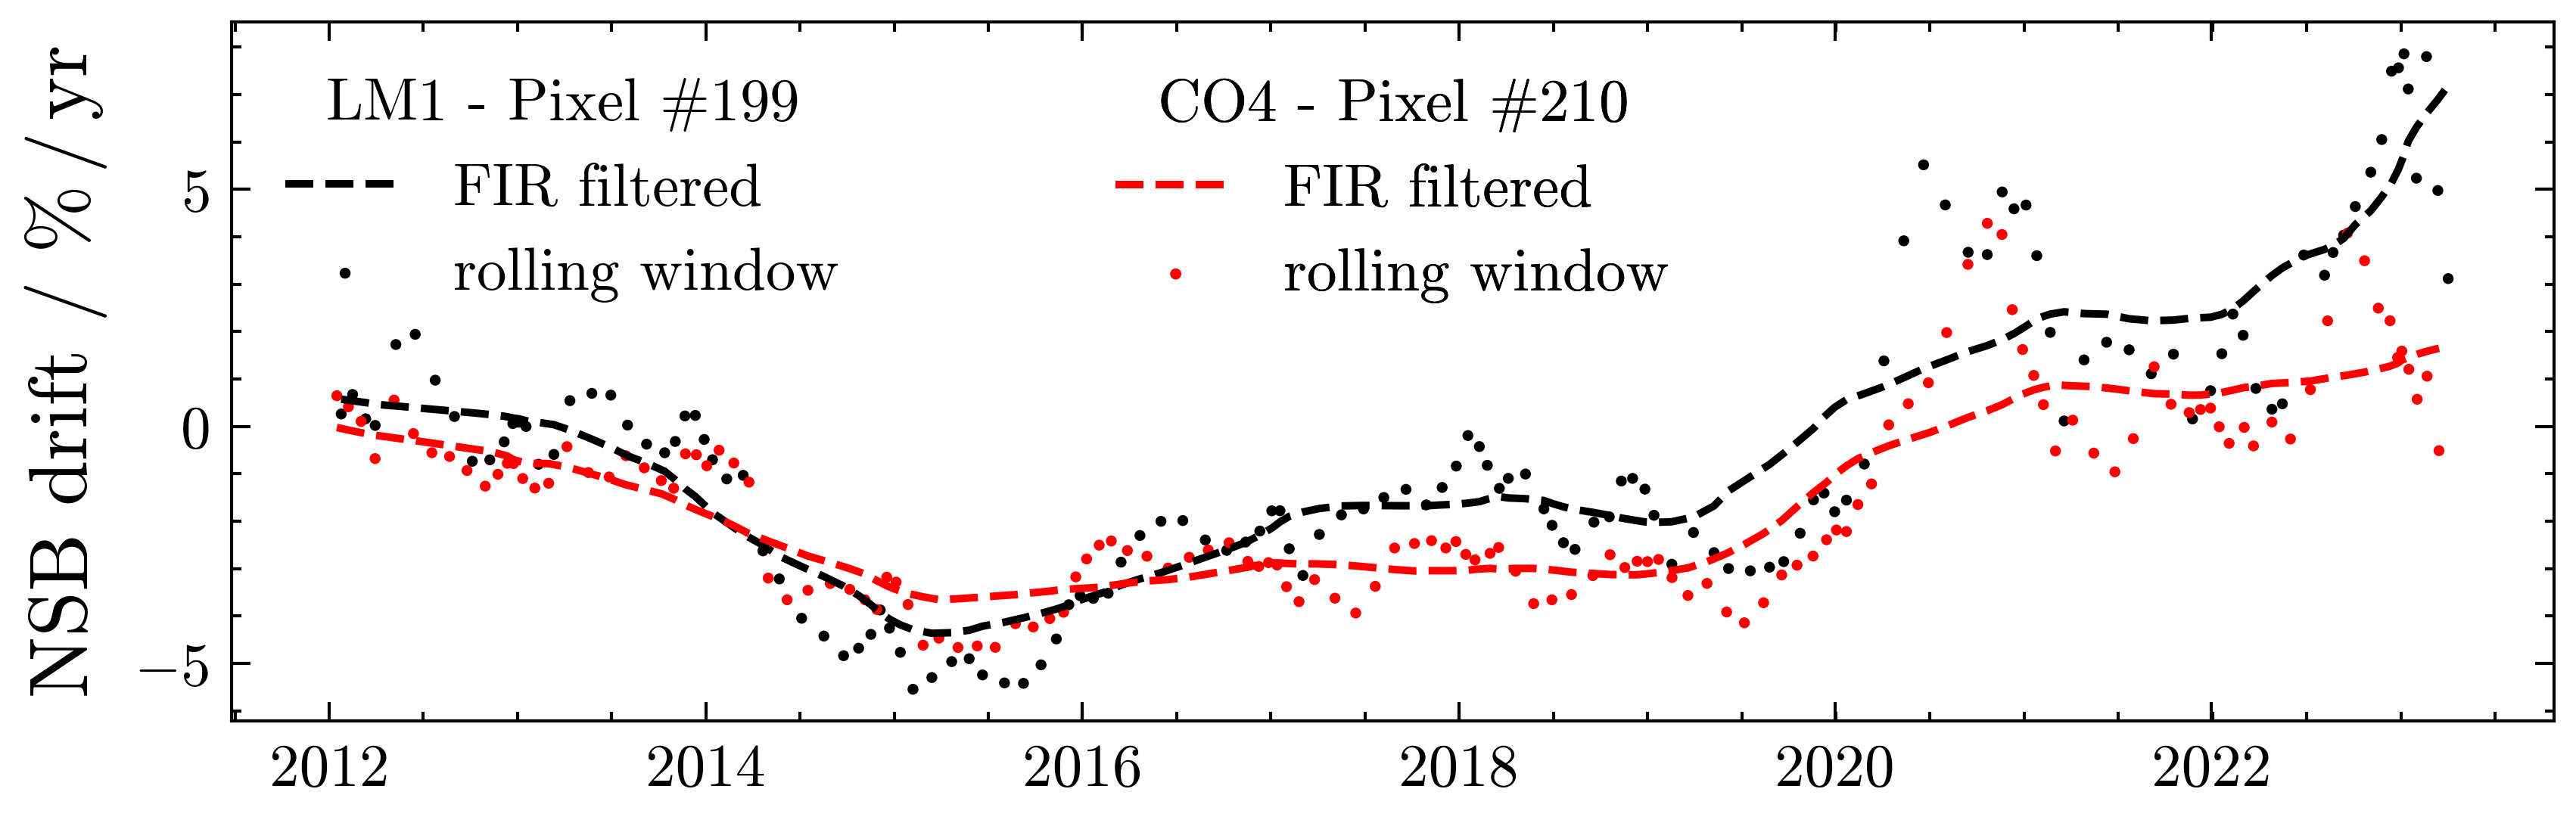

In [70]:
set_plt_style('slim')

fig = plt.figure(figsize=[6.6, 2])
drifts_filtered = savgol_filter(drifts_lm1, 24, 1)
l2, = plt.plot(times_lm1, drifts_filtered, marker='none', label='FIR filtered', lw=1.2, ls='--')
drifts_filtered = savgol_filter(drifts_co4, 24, 1)
l4, = plt.plot(times_co4, drifts_filtered, marker='none', label='FIR filtered', lw=1.2, ls='--')

l1 = plt.scatter(times_lm1, drifts_lm1, label='rolling window', ec='none', s=3)
l3 = plt.scatter(times_co4, drifts_co4, label='rolling window', ec='none', s=3)


# plt.legend(title='LM1 - Pixel $\#199$')

plt.ylabel("NSB drift / $\%\,/\,\mathrm{yr}$")
# plt.ylim(-5, 5)

leg1 = plt.legend(handles=[l2, l1], title='LM1 - Pixel $\#199$', loc='upper left')
plt.gca().add_artist(leg1)
leg2 = plt.legend(handles=[l4, l3], title='CO4 - Pixel $\#210$', loc='upper center')
plt.gca().add_artist(leg2)

plot.save(plt.gcf(), "nsb_thesis_plots/rolling_window_drift")